<a href="https://colab.research.google.com/github/niya-c-anto/Learnings/blob/main/Pytorch_and_optimisation_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries needed for pytorch introduction for nn

In [36]:
#for the implementation of nn and optimisation
import torch
import torch.nn as nn
#weight and bias tensors part of neural network
import torch.nn.functional as F
#activation functions
from torch.optim import SGD
#stochastic gradient descent

#for graphs
import matplotlib.pyplot as plt
import seaborn as sns#samual norman seaborn west wing novel

In [37]:
#creating a new class is creating new neural network in pytorch
class BasicNN(nn.Module):#pytorch class module
  def __init__(self):#initialisation
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)#nn is neural network parameter
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)#weights and biases
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w010 = nn.Parameter(torch.tensor(2.7),requires_grad=False)
    self.final_bias = nn.Parameter(torch.tensor(-16.),requires_grad=False)
#connecting the weights and biases to activation function and to output so we do a forward alongside
  def forward(self,input):
    input_to_top_relu = input*self.w00+self.b00
    top_relu_output = F.relu(input_to_top_relu)#relu activation is used
    scaled_top_relu_output = top_relu_output * self.w01

    input_to_bottom_relu = input*self.w10+self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output * self.w010

    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias#all r added
    output = F.relu(input_to_final_relu)

    return output

In [38]:
input_doses = torch.linspace(start=0,end =1,steps =11)
input_doses #sequence of input values as tensor

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])

Text(0.5, 0, 'dose')

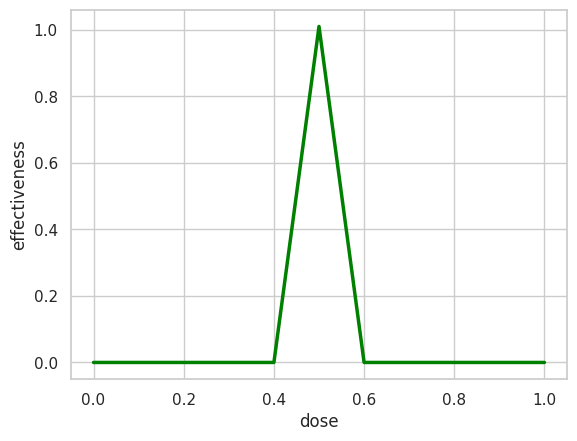

In [39]:
#to have tis as a graph
model =BasicNN()
output_values = model(input_doses)
sns.set(style="whitegrid")
sns.lineplot(x=input_doses,y=output_values,color = "green",linewidth =2.5)
plt.ylabel('effectiveness')
plt.xlabel('dose')


In [25]:
#we r using another subfinal bias now with backpropogation
class BasicNN_train(nn.Module):
  def __init__(self):
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w010 = nn.Parameter(torch.tensor(2.7),requires_grad=False)
    self.final_bias = nn.Parameter(torch.tensor(0.),requires_grad=True)#optimisation happens when its true

  def forward(self,input):
    input_to_top_relu = input*self.w00+self.b00
    top_relu_output = F.relu(input_to_top_relu)
    scaled_top_relu_output = top_relu_output * self.w01

    input_to_bottom_relu = input*self.w10+self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output * self.w010

    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias
    output = F.relu(input_to_final_relu)

    return output

Text(0.5, 0, 'dose')

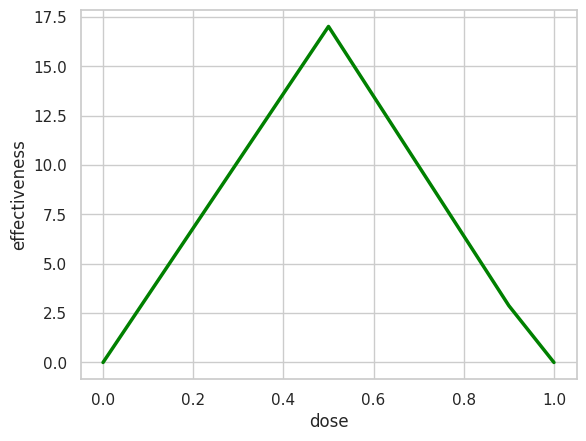

In [22]:
model =BasicNN_train()#it is coming from ttrain and not basic nn
output_values = model(input_doses)
sns.set(style="whitegrid")
sns.lineplot(x=input_doses,y=output_values.detach(),color = "green",linewidth =2.5)
plt.ylabel('effectiveness')
plt.xlabel('dose')

In [31]:
inputs = torch.tensor([0.,0.5,1.])
labels = torch.tensor([0.,1.,0.])

In [32]:
from typing import Final
optimizer = SGD(model.parameters(),lr=0.1)
print('Final bias,before  optimization: '+str(model.final_bias.data)+"\n")
for epoch in range(100):
  total_loss =0
  for iteration in range(len(inputs)):
    input_i = inputs[iteration]
    label_i =labels[iteration]
    output_i = model(input_i)
    loss = (output_i - label_i)**2
    loss.backward()
    total_loss +=float(loss)
  if(total_loss<0.0001):
    print("Num steps: "+str(epoch))
    break
  optimizer.step()
  optimizer.zero_grad()
  print("Step: "+str(epoch)+"Final bias: "+str(model.final_bias.data)+"\n")
  print("Final bias,after optimisation: "+str(model.final_bias.data))

Final bias,before  optimization: tensor(0.)

Step: 0Final bias: tensor(-3.2020)

Final bias,after optimisation: tensor(-3.2020)
Step: 1Final bias: tensor(-5.7636)

Final bias,after optimisation: tensor(-5.7636)
Step: 2Final bias: tensor(-7.8129)

Final bias,after optimisation: tensor(-7.8129)
Step: 3Final bias: tensor(-9.4523)

Final bias,after optimisation: tensor(-9.4523)
Step: 4Final bias: tensor(-10.7638)

Final bias,after optimisation: tensor(-10.7638)
Step: 5Final bias: tensor(-11.8131)

Final bias,after optimisation: tensor(-11.8131)
Step: 6Final bias: tensor(-12.6525)

Final bias,after optimisation: tensor(-12.6525)
Step: 7Final bias: tensor(-13.3240)

Final bias,after optimisation: tensor(-13.3240)
Step: 8Final bias: tensor(-13.8612)

Final bias,after optimisation: tensor(-13.8612)
Step: 9Final bias: tensor(-14.2909)

Final bias,after optimisation: tensor(-14.2909)
Step: 10Final bias: tensor(-14.6348)

Final bias,after optimisation: tensor(-14.6348)
Step: 11Final bias: tensor(

/tmp/ipykernel_5897/4172073744.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss +=float(loss)


Text(0.5, 0, 'dose')

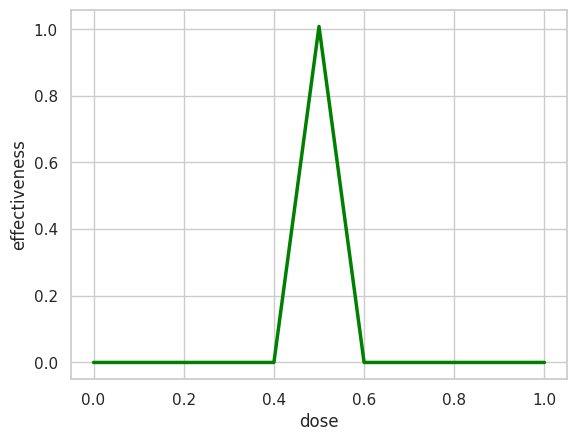

In [33]:
output_values = model(input_doses)
sns.set(style="whitegrid")
sns.lineplot(x=input_doses,y=output_values.detach(),color = "green",linewidth =2.5)
plt.ylabel('effectiveness')
plt.xlabel('dose')